# Авито Подработка. Финальное исследование

В этом исследовании проверяется одна основная гипотеза: Пользователи, у которых уже есть признаки интереса к подработке или гибкой занятости в Авито Работе, чаще доходят до первой брони смены в Авито Подработке

Почему это важно: Авито Подработке нужно растить базу исполнителей и доводить пользователей до первого продуктового действия. В этом датасете таким действием считается первая бронь смены

Логика исследования:
1. Проверяем качество данных и не удаляем строки без понятной причины
2. Собираем признак интереса к подработке и смотрим, из каких сигналов он состоит
3. Сравниваем конверсии, проверяем статистическую значимость и отдельно смотрим, не объясняется ли результат общей активностью пользователя в Авито Работе

Главное ограничение: Данные наблюдательные. Они хорошо подходят, чтобы найти устойчивую связь и выбрать идею для эксперимента с контрольной и тестовой группой, но не доказывают причинность так же сильно, как настоящий эксперимент, где пользователей случайно делят на группы

## Мини-словарь по исследованию

Теплая аудитория - это пользователи, у которых в данных есть признаки интереса к подработке. Например, они откликались на вакансии типа подработки, указали подработку в резюме или указали свободный график

Аудитория без признаков интереса - это пользователи, у которых таких сигналов нет. Это не значит, что они точно не заинтересованы. Это значит только то, что в данных нет явных признаков интереса

Конверсия - это доля пользователей, сделавших нужное действие. В этом исследовании главное действие - первая бронь смены

Процентный пункт нужен, чтобы корректно читать разницу между долями. Если конверсия выросла с 3% до 5%, разница равна 2 процентным пунктам. Относительный рост при этом равен примерно 67%, потому что 5% больше 3% в 1.67 раза

Контрольная переменная - это фактор, добавленный в модель для более честного сравнения. Например, количество откликов на вакансии. Если его не учесть, можно перепутать интерес к подработке с общей активностью пользователя

p-value - это проверка на случайный шум. Низкое p-value не доказывает причинность, но показывает, что найденная разница плохо похожа на случайное совпадение

## 0. Импорты и настройки

Подключаем библиотеки и готовим простые функции для красивого вывода таблиц

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import statsmodels.formula.api as smf

In [2]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 100

OUT = Path("avito_case_final_results")
OUT.mkdir(parents=True, exist_ok=True)


def save_table(data, name):
    path = OUT / name
    data.to_csv(path, index=False)
    return path


def pct(x, digits=1):
    if pd.isna(x):
        return ""
    return f"{x:.{digits}%}"


def pp(x, digits=2):
    if pd.isna(x):
        return ""
    return f"{x:.{digits}f} п.п."


def pvalue_fmt(x):
    if pd.isna(x):
        return ""
    if x < 0.001:
        return "< 0.001"
    return f"{x:.3f}"


RUSSIAN_COLUMN_NAMES = {
    "column": "Колонка",
    "dtype": "Тип данных",
    "missing": "Пропуски",
    "missing_share": "Доля пропусков",
    "unique": "Уникальные значения",
    "metric": "Показатель",
    "value": "Значение",
    "stage": "Шаг",
    "n": "Пользователи",
    "share_of_all": "Доля от всех",
    "share_of_previous": "Доля от прошлого шага",
    "segment": "Сегмент",
    "segment_users": "Размер сегмента",
    "share_of_segment": "Доля внутри сегмента",
    "interest_segment": "Сегмент интереса",
    "users": "Пользователи",
    "booked": "Забронировали",
    "booked_first_shift": "Забронировали первую смену",
    "booking_cr": "Конверсия в первую бронь",
    "signal": "Сигнал",
    "users_with_signal": "Пользователи с сигналом",
    "booked_with_signal": "Брони среди пользователей с сигналом",
    "cr_with_signal": "Конверсия с сигналом",
    "cr_without_signal": "Конверсия без сигнала",
    "diff_pp": "Разница, п.п.",
    "variant": "Вариант расчета",
    "warm_users": "Теплая аудитория, пользователей",
    "cold_users": "Аудитория без признаков интереса, пользователей",
    "warm_cr": "Конверсия теплой аудитории",
    "cold_cr": "Конверсия аудитории без признаков интереса",
    "warm_n": "Теплая аудитория, пользователей",
    "cold_n": "Аудитория без признаков интереса, пользователей",
    "warm_rate": "Доля теплой аудитории",
    "cold_rate": "Доля аудитории без признаков интереса",
    "p_value": "p-value",
    "rows_in_duplicate_groups": "Строки в группах полных дублей",
    "rows_removed_by_drop_duplicates": "Строки, которые удалит drop_duplicates",
    "share_in_duplicate_groups": "Доля строк в группах полных дублей",
    "share_removed_by_drop_duplicates": "Доля строк к удалению",
    "quantity_responses": "Количество откликов",
    "avg_quantity_responses": "Среднее количество откликов",
    "median_quantity_responses": "Медианное количество откликов",
    "responses_bin": "Группа по количеству откликов",
    "model": "Модель",
    "effect_of_interest_pp": "Эффект признаков интереса, п.п.",
    "effect_pp_after_activity_control": "Эффект после учета активности, п.п.",
    "ci_low_pp": "Нижняя граница интервала, п.п.",
    "ci_high_pp": "Верхняя граница интервала, п.п.",
    "r2": "R2 модели",
    "factor": "Техническое название разреза",
    "factor_name": "Разрез",
    "group": "Группа",
    "groups_checked": "Проверено групп",
    "groups_where_warm_higher": "Групп, где теплая аудитория выше",
    "significant_groups_5pct": "Значимых групп на уровне 5%",
    "median_diff_pp": "Медианная разница, п.п.",
    "min_diff_pp": "Минимальная разница, п.п.",
    "max_diff_pp": "Максимальная разница, п.п.",
    "share_groups_warm_higher": "Доля групп, где теплая аудитория выше",
    "block": "Блок",
    "result": "Результат",
}


def display_formatted(data, percent_cols=None, pp_cols=None, pvalue_cols=None, int_cols=None, max_rows=30):
    percent_cols = percent_cols or []
    pp_cols = pp_cols or []
    pvalue_cols = pvalue_cols or []
    int_cols = int_cols or []

    out = data.copy()
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pct(x))
    for col in pp_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pp(x))
    for col in pvalue_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pvalue_fmt(x))
    for col in int_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"{int(x):,}".replace(",", " ") if pd.notna(x) else "")
    display(out.rename(columns=RUSSIAN_COLUMN_NAMES).head(max_rows))

# Часть 1. Преданализ и подготовка данных

Смотрим, что лежит в данных, дабы не строить выводы на грязной базе. Важно не удалять строки автоматически. Если есть пропуски, дубли или странные сочетания событий, сначала считаем их размер и только потом решаем, как с ними работать

## 1. Загрузка данных

Загружаем файл и смотрим размер датасета. Это база для всех дальнейших долей, конверсий и статистических тестов

In [3]:
df_raw = pd.read_csv('dataset_avito.csv')
df = df_raw.copy()

print(f"Размер исходного датасета: {df.shape[0]:,} строк и {df.shape[1]} колонок".replace(",", " "))
display(df.head())

Размер исходного датасета: 25 328 строк и 48 колонок


,gender,age,income,platform,app_version,serp_frequency,item_view_frequency,region,started_verification_gu_flg,success_verification_gu_flg,shift_booked_time_1,shift_start_time_1,job_done_1,shift_duration_1,shift_price_per_hour_1,task_type_1,task_group_1,shift_region_1,shift_booked_time_2,shift_start_time_2,job_done_2,shift_duration_2,shift_price_per_hour_2,task_type_2,task_group_2,shift_region_2,shift_booked_time_3,shift_start_time_3,job_done_3,shift_duration_3,shift_price_per_hour_3,task_type_3,task_group_3,shift_region_3,cv_titles,cv_professions,cv_free_grafik_flg,cv_podrabotka_flg,quantity_responses,vac_titles,vac_professions,vac_schedules,vac_podrabotka_flg,click_internet_adv_flg,opened_push_flg,watched_stories_in_app_flg,click_addv_communication_flg,has_call_centre_communication_flg
0,NaN,NaN,NaN,iOS,200.0,2,0,Краснодарский край,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Администратор,администратор,0,0,6,Продавец без опыта 585*Золотой стц Мега; Админ...,Продавец-консультант; Администратор; Менеджер ...,Сменный,0,0,0,0,0,0
1,NaN,NaN,NaN,Android,197.5,2,0,Нижегородская область,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,Оператор станков чпу,Оператор станка,Сменный,1,1,0,1,0,0
2,woman,1.0,2.0,iOS,200.0,3,0,Краснодарский край,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Продавец-консультант,продавец-консультант,0,0,8,Бариста в кофейню; Продавец консультант в мага...,Бариста; Продавец-консультант; Работник торгов...,Сменный; Фиксированный,1,0,0,0,0,0
3,NaN,NaN,NaN,MAV,NaN,1,0,Краснодарский край,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,Водитель категории с (развоз по точкам),Водитель грузового транспорта,Фиксированный,0,0,0,0,0,0
4,NaN,NaN,NaN,Android,199.0,1,0,Свердловская область,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0


## 2. Структура данных и пропуски

Смотрим типы колонок, количество пропусков и число уникальных значений

Как читать таблицу

Если в колонках про вторую или третью смену много пропусков, это нормально. Значит пользователь не дошел до этих смен. Если пропуски есть в демографии, мы не удаляем таких пользователей. В моделях такие значения попадут в отдельную группу «значение неизвестно», чтобы не потерять часть аудитории

Зачем это нужно

Если молча удалить все строки с пропусками, можно случайно изменить состав аудитории и получить красивый, но неправильный результат. Поэтому сначала фиксируем масштаб пропусков, а уже потом решаем, как с ними работать

In [4]:
schema = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns],
    "missing_share": [df[c].isna().mean() for c in df.columns],
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
}).sort_values("missing_share", ascending=False)

save_table(schema, "01_schema_missing.csv")
display_formatted(
    schema,
    percent_cols=["missing_share"],
    int_cols=["missing", "n_unique"],
    max_rows=20,
)

,Колонка,Тип данных,Пропуски,Доля пропусков,n_unique
28,job_done_3,object,25 088,99.1%,1
20,job_done_2,object,25 008,98.7%,1
12,job_done_1,object,24 846,98.1%,1
27,shift_start_time_3,object,24 319,96.0%,647
29,shift_duration_3,float64,24 319,96.0%,14
31,task_type_3,object,24 319,96.0%,15
30,shift_price_per_hour_3,float64,24 319,96.0%,1 009
26,shift_booked_time_3,object,24 319,96.0%,1 009
32,task_group_3,object,24 319,96.0%,6
33,shift_region_3,object,24 319,96.0%,8


## 3. Проверка полных дублей

Дубли важно проверить отдельно

Основной анализ я оставляю на всех строках, потому что в данных нет идентификатора пользователя `user_id`. Без него нельзя строго доказать, что две одинаковые строки это один и тот же пользователь: одинаковые строки могут быть дублем, а могут быть двумя разными пользователями с одинаковыми значениями признаков

Ниже обязательно повторим основной расчет без полных дублей - это проверка, не держится ли результат только на дублях. Если вывод сохраняется и после такой проверки, к нему больше доверия

In [5]:
duplicate_report = pd.DataFrame({
    "metric": [
        "Всего строк",
        "Строк, которые были бы удалены при удалении полных дублей",
        "Строк, входящих в группы полных дублей",
        "Строк осталось бы после удаления полных дублей",
    ],
    "value": [
        len(df_raw),
        int(df_raw.duplicated().sum()),
        int(df_raw.duplicated(keep=False).sum()),
        len(df_raw.drop_duplicates()),
    ],
})

duplicate_report["share_of_all"] = duplicate_report["value"] / len(df_raw)
save_table(duplicate_report, "02_duplicate_report.csv")
display_formatted(duplicate_report, percent_cols=["share_of_all"], int_cols=["value"], max_rows=10)

,Показатель,Значение,Доля от всех
0,Всего строк,25 328,100.0%
1,"Строк, которые были бы удалены при удалении по...",2 455,9.7%
2,"Строк, входящих в группы полных дублей",3 394,13.4%
3,Строк осталось бы после удаления полных дублей,22 873,90.3%


## 4. Даты и целевые переменные

Главные переменные:
- `booked_first_shift` показывает, что пользователь забронировал первую смену: если заполнено время брони первой смены, ставим 1, иначе 0
- `done_first_shift` показывает, что первая смена успешно завершена: если `job_done_1` равен `True`, ставим 1, иначе 0

Бронь - это основная метрика активации. Успешное завершение смотрим отдельно, чтобы не сделать слишком сильный вывод. Пользователь может чаще бронировать, но это не значит, что он лучше выходит на смену

In [6]:
date_cols = [
    "shift_booked_time_1", "shift_start_time_1",
    "shift_booked_time_2", "shift_start_time_2",
    "shift_booked_time_3", "shift_start_time_3",
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")


def true_to_int(x):
    return 1 if str(x).lower() == "true" else 0


for col in [
    "started_verification_gu_flg",
    "success_verification_gu_flg",
    "vac_podrabotka_flg",
    "cv_podrabotka_flg",
    "cv_free_grafik_flg",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)


df["booked_first_shift"] = df["shift_booked_time_1"].notna().astype(int)
df["done_first_shift"] = df["job_done_1"].map(true_to_int).astype(int)

checks_target = pd.DataFrame({
    "metric": [
        "Пользователей всего",
        "Забронировали первую смену",
        "Успешно завершили первую смену",
        "Завершили первую смену среди забронировавших",
    ],
    "n": [
        len(df),
        int(df["booked_first_shift"].sum()),
        int(df["done_first_shift"].sum()),
        int(df.loc[df["booked_first_shift"] == 1, "done_first_shift"].sum()),
    ],
})
checks_target["share"] = [
    1,
    df["booked_first_shift"].mean(),
    df["done_first_shift"].mean(),
    df.loc[df["booked_first_shift"] == 1, "done_first_shift"].mean(),
]

save_table(checks_target, "03_target_variables.csv")
display_formatted(checks_target, percent_cols=["share"], int_cols=["n"], max_rows=10)

,Показатель,Пользователи,share
0,Пользователей всего,25 328,100.0%
1,Забронировали первую смену,2 370,9.4%
2,Успешно завершили первую смену,482,1.9%
3,Завершили первую смену среди забронировавших,482,20.3%


## 5. Логические проверки

Проверяем невозможные логически сочетания событий, например, бронь без успешной верификации

Как читать результат

Если таких строк мало, не удаляем их из основного анализа, но фиксируем, что в логах есть нюансы. Это лучше, чем чистить данные, не объясняя, что именно было удалено

In [7]:
logic_checks = pd.DataFrame({
    "check": [
        "Успешная верификация есть, а старта верификации нет",
        "Первая бронь есть, а успешной верификации нет",
        "Старт первой смены есть, а брони нет",
        "Успешная первая смена есть, а брони нет",
    ],
    "n": [
        int(((df["success_verification_gu_flg"] == 1) & (df["started_verification_gu_flg"] == 0)).sum()),
        int(((df["booked_first_shift"] == 1) & (df["success_verification_gu_flg"] == 0)).sum()),
        int((df["shift_start_time_1"].notna() & df["shift_booked_time_1"].isna()).sum()),
        int(((df["done_first_shift"] == 1) & (df["booked_first_shift"] == 0)).sum()),
    ],
})
logic_checks["share_of_all"] = logic_checks["n"] / len(df)
logic_checks["decision"] = "Не удаляем из основного анализа, учитываем как нюанс данных"

save_table(logic_checks, "04_logic_checks.csv")
display_formatted(logic_checks, percent_cols=["share_of_all"], int_cols=["n"], max_rows=10)

,check,Пользователи,Доля от всех,decision
0,"Успешная верификация есть, а старта верификаци...",28,0.1%,"Не удаляем из основного анализа, учитываем как..."
1,"Первая бронь есть, а успешной верификации нет",4,0.0%,"Не удаляем из основного анализа, учитываем как..."
2,"Старт первой смены есть, а брони нет",0,0.0%,"Не удаляем из основного анализа, учитываем как..."
3,"Успешная первая смена есть, а брони нет",0,0.0%,"Не удаляем из основного анализа, учитываем как..."


## 6. Лаг между бронью и стартом смены

Это вспомогательная проверка качества дат. Если старт смены стоит раньше брони, такой лаг нельзя использовать как нормальное время ожидания

Строки из анализа не удаляем. Факт брони и факт успешной смены не трогаем. Отрицательный лаг заменяем пустым значением в отдельной колонке лага

In [8]:
lag_report = []

for i in [1, 2, 3]:
    booked_col = f"shift_booked_time_{i}"
    start_col = f"shift_start_time_{i}"
    lag_col = f"booking_to_start_hours_{i}"

    if booked_col in df.columns and start_col in df.columns:
        df[lag_col] = (df[start_col] - df[booked_col]).dt.total_seconds() / 3600
        bad_lag = df[booked_col].notna() & df[start_col].notna() & (df[lag_col] < 0)

        lag_report.append({
            "shift_number": i,
            "rows_with_both_dates": int((df[booked_col].notna() & df[start_col].notna()).sum()),
            "negative_lag_rows": int(bad_lag.sum()),
            "negative_lag_share": bad_lag.mean(),
            "decision": "Отрицательный лаг заменен на NaN только в колонке лага",
        })

        df.loc[bad_lag, lag_col] = np.nan

lag_report = pd.DataFrame(lag_report)
save_table(lag_report, "05_lag_report.csv")
display_formatted(
    lag_report,
    percent_cols=["negative_lag_share"],
    int_cols=["rows_with_both_dates", "negative_lag_rows"],
    max_rows=10,
)

,shift_number,rows_with_both_dates,negative_lag_rows,negative_lag_share,decision
0,1,2 370,0,0.0%,Отрицательный лаг заменен на NaN только в коло...
1,2,1 399,2,0.0%,Отрицательный лаг заменен на NaN только в коло...
2,3,1 009,0,0.0%,Отрицательный лаг заменен на NaN только в коло...


## 7. Числовые признаки и хвосты распределений

Цель шага - понимание диапазонов значений, а не поиск идеальных выбросов для удаления

Как читать таблицу

`p99` это 99-й перцентиль - значение, ниже которого лежит 99 процентов пользователей. Если максимум сильно выше `p99`, значит есть длинный хвост, например, у большинства пользователей может быть мало откликов, а у небольшой части очень много

Для текущего исследования это не ломает основной расчет, так как главная метрика бинарна, но для моделей с количеством откликов ниже используется логарифм от количества откликов плюс один. Такой прием сжимает очень большие значения и не дает нескольким сверхактивным пользователям слишком сильно влиять на модель

In [9]:
numeric_cols = [
    "serp_frequency", "item_view_frequency", "quantity_responses",
    "shift_duration_1", "shift_price_per_hour_1",
    "age", "income",
]

numeric_report = []
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        x = df[col]
        numeric_report.append({
            "column": col,
            "non_missing": int(x.notna().sum()),
            "missing": int(x.isna().sum()),
            "min": x.min(),
            "p50": x.quantile(0.5),
            "p95": x.quantile(0.95),
            "p99": x.quantile(0.99),
            "max": x.max(),
        })

numeric_report = pd.DataFrame(numeric_report)
save_table(numeric_report, "06_numeric_report.csv")
display_formatted(numeric_report, int_cols=["non_missing", "missing"], max_rows=20)

,Колонка,non_missing,Пропуски,min,p50,p95,p99,max
0,serp_frequency,25 328,0,1.000000,1.000000,13.000000,72.000000,1006.000000
1,item_view_frequency,25 328,0,0.000000,0.000000,9.000000,22.000000,183.000000
2,quantity_responses,25 328,0,0.000000,3.000000,76.000000,180.730000,852.000000
3,shift_duration_1,2 370,22 958,1.000000,12.000000,13.000000,14.000000,16.000000
4,shift_price_per_hour_1,2 370,22 958,10.374151,355.324997,555.465323,646.053285,1045.947791
5,age,14 446,10 882,0.000000,2.000000,4.000000,4.000000,5.000000
6,income,14 446,10 882,1.000000,2.000000,3.000000,4.000000,4.000000


## 8. Подготовка категорий для моделей

Демография, платформа и регион нужны для проверки альтернативных объяснений. Например, может оказаться, что конверсия выше не из-за интереса к подработке, а из-за региона, платформы или возрастной группы

Как считаем

Пропуски превращаем в отдельную группу «значение неизвестно». Редкие регионы объединяем в группу «другое», чтобы модель не распалась на очень маленькие группы

Зачем это нужно

Если в модели будет слишком много маленьких групп, оценки по ним станут нестабильными и модель может начать объяснять случайные колебания, а не реальную связь в данных

In [10]:
def format_category_value(x):
    if pd.isna(x):
        return "Значение неизвестно"
    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    return str(x)


def top_categories_or_other(series, top_n=15, other_name="Другое"):
    s = series.map(format_category_value)
    top_values = s.value_counts().head(top_n).index
    return s.where(s.isin(top_values), other_name)


category_settings = {
    "gender": 10,
    "age": 10,
    "income": 10,
    "platform": 10,
    "region": 15,
}

for col, top_n in category_settings.items():
    if col in df.columns:
        df[f"{col}_model"] = top_categories_or_other(df[col], top_n=top_n)

marketing_flags = [
    "click_internet_adv_flg",
    "opened_push_flg",
    "watched_stories_in_app_flg",
    "click_addv_communication_flg",
    "has_call_centre_communication_flg",
]

for col in marketing_flags:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# Количество откликов дальше используем как контроль общей активности в Авито Работе.
df["quantity_responses_num"] = pd.to_numeric(df["quantity_responses"], errors="coerce").fillna(0)
df["log_quantity_responses"] = np.log1p(df["quantity_responses_num"])

# Часть 2. Гипотеза и основной расчет

Переходим к гипотезе:
1. Собираем признак интереса к подработке
2. смотрим воронку, конверсии и статистическую значимость

## 9. Признак интереса к подработке

Используем формулировку `есть признаки интереса к подработке`. Это аналитический сегмент, а не новый продуктовый термин

Пользователь попадает в этот сегмент, если у него есть хотя бы один из трех сигналов: он откликался на вакансии типа подработки, указал подработку в резюме или указал свободный график в резюме

Как читать результат

Если у пользователя есть хотя бы один сигнал, ставим `has_podrabotka_interest = 1`, иначе ставим 0

In [11]:
podrabotka_interest_components = [
    "vac_podrabotka_flg",
    "cv_podrabotka_flg",
    "cv_free_grafik_flg",
]

missing_interest_cols = [c for c in podrabotka_interest_components if c not in df.columns]
if missing_interest_cols:
    raise ValueError(f"В датасете нет колонок для формирования признака интереса: {missing_interest_cols}")

df["has_podrabotka_interest"] = df[podrabotka_interest_components].max(axis=1).astype(int)
df["interest_segment"] = df["has_podrabotka_interest"].map({
    0: "Нет признаков интереса к подработке",
    1: "Есть признаки интереса к подработке",
})

interest_distribution = (
    df.groupby("interest_segment")
    .agg(
        users=("booked_first_shift", "size"),
        booked_first_shift=("booked_first_shift", "sum"),
        booking_cr=("booked_first_shift", "mean"),
    )
    .reset_index()
)
interest_distribution["share_of_all"] = interest_distribution["users"] / len(df)

save_table(interest_distribution, "07_interest_distribution.csv")
display_formatted(
    interest_distribution,
    percent_cols=["booking_cr", "share_of_all"],
    int_cols=["users", "booked_first_shift"],
    max_rows=10,
)

,Сегмент интереса,Пользователи,Забронировали первую смену,Конверсия в первую бронь,Доля от всех
0,Есть признаки интереса к подработке,15 562,2 004,12.9%,61.4%
1,Нет признаков интереса к подработке,9 766,366,3.7%,38.6%


## 10. Из каких сигналов состоит интерес

Общий флаг интереса широкий, поэтому нельзя сразу считать его одним чистым фактором. Сначала смотрим каждый сигнал отдельно, а потом разбиваем пользователей на взаимоисключающие группы

Это нужно, чтобы понять реальную связь сигнала с бронью. Например, если весь эффект идет от откликов на вакансии, то не стоит делать общий вывод про любые признаки интереса в резюме

In [12]:
component_names = {
    "vac_podrabotka_flg": "Откликался на вакансии типа подработки",
    "cv_podrabotka_flg": "Указал подработку в резюме",
    "cv_free_grafik_flg": "Указал свободный график в резюме",
}

interest_components = []
for col in podrabotka_interest_components:
    g = df.groupby(col)["booked_first_shift"].agg(["count", "sum", "mean"]).reset_index()
    yes = g[g[col] == 1]
    no = g[g[col] == 0]
    if len(yes) and len(no):
        interest_components.append({
            "signal": component_names.get(col, col),
            "users_with_signal": int(yes["count"].iloc[0]),
            "booked_with_signal": int(yes["sum"].iloc[0]),
            "cr_with_signal": float(yes["mean"].iloc[0]),
            "cr_without_signal": float(no["mean"].iloc[0]),
            "diff_pp": float((yes["mean"].iloc[0] - no["mean"].iloc[0]) * 100),
        })

interest_components_df = pd.DataFrame(interest_components).sort_values("diff_pp", ascending=False)
save_table(interest_components_df, "08_interest_components.csv")
display_formatted(
    interest_components_df,
    percent_cols=["cr_with_signal", "cr_without_signal"],
    pp_cols=["diff_pp"],
    int_cols=["users_with_signal", "booked_with_signal"],
    max_rows=10,
)

,Сигнал,Пользователи с сигналом,Брони среди пользователей с сигналом,Конверсия с сигналом,Конверсия без сигнала,"Разница, п.п."
0,Откликался на вакансии типа подработки,15 024,1 985,13.2%,3.7%,9.48 п.п.
1,Указал подработку в резюме,5 629,808,14.4%,7.9%,6.42 п.п.
2,Указал свободный график в резюме,5 193,723,13.9%,8.2%,5.74 п.п.


In [13]:
def make_interest_signal_group(row):
    has_vac = row["vac_podrabotka_flg"] == 1
    has_cv_podrabotka = row["cv_podrabotka_flg"] == 1
    has_cv_free = row["cv_free_grafik_flg"] == 1

    if not has_vac and not has_cv_podrabotka and not has_cv_free:
        return "0. Нет сигналов"
    if has_vac and not has_cv_podrabotka and not has_cv_free:
        return "1. Только отклик на вакансии типа подработки"
    if not has_vac and has_cv_podrabotka and not has_cv_free:
        return "2. Только подработка в резюме"
    if not has_vac and not has_cv_podrabotka and has_cv_free:
        return "3. Только свободный график в резюме"
    if not has_vac and has_cv_podrabotka and has_cv_free:
        return "4. Подработка и свободный график в резюме"
    if has_vac and (has_cv_podrabotka or has_cv_free):
        return "5. Отклик на подработку плюс другие сигналы"
    return "6. Другое"


df["interest_signal_group"] = df.apply(make_interest_signal_group, axis=1)

interest_signal_groups = (
    df.groupby("interest_signal_group")
    .agg(
        users=("booked_first_shift", "size"),
        booked=("booked_first_shift", "sum"),
        booking_cr=("booked_first_shift", "mean"),
        avg_quantity_responses=("quantity_responses_num", "mean"),
    )
    .reset_index()
    .sort_values("interest_signal_group")
)
interest_signal_groups["share_of_all"] = interest_signal_groups["users"] / len(df)

save_table(interest_signal_groups, "09_interest_signal_groups.csv")
display_formatted(
    interest_signal_groups,
    percent_cols=["booking_cr", "share_of_all"],
    int_cols=["users", "booked"],
    max_rows=20,
)

,interest_signal_group,Пользователи,Забронировали,Конверсия в первую бронь,Среднее количество откликов,Доля от всех
0,0. Нет сигналов,9 766,366,3.7%,0.238890,38.6%
1,1. Только отклик на вакансии типа подработки,8 875,1 038,11.7%,20.979831,35.0%
2,2. Только подработка в резюме,123,5,4.1%,1.349593,0.5%
3,3. Только свободный график в резюме,116,3,2.6%,1.784483,0.5%
4,4. Подработка и свободный график в резюме,299,11,3.7%,0.648829,1.2%
5,5. Отклик на подработку плюс другие сигналы,6 149,947,15.4%,35.123435,24.3%


### Что видно по сигналам

Самый сильный сигнал связан с откликами на вакансии типа подработки. Сигналы из резюме без отклика на такие вакансии почти не отличаются от группы без сигналов

Это важно для выводов. Теплую аудиторию нельзя читать как один однородный сегмент

Более точная интерпретация

в данных лучше всего выделяются пользователи, которые уже были активны в Авито Работе и особенно взаимодействовали с вакансиями типа подработки

Для продукта это значит, что коммуникацию лучше строить не на широком признаке «когда-то указал свободный график», а на более сильных сигналах поведения

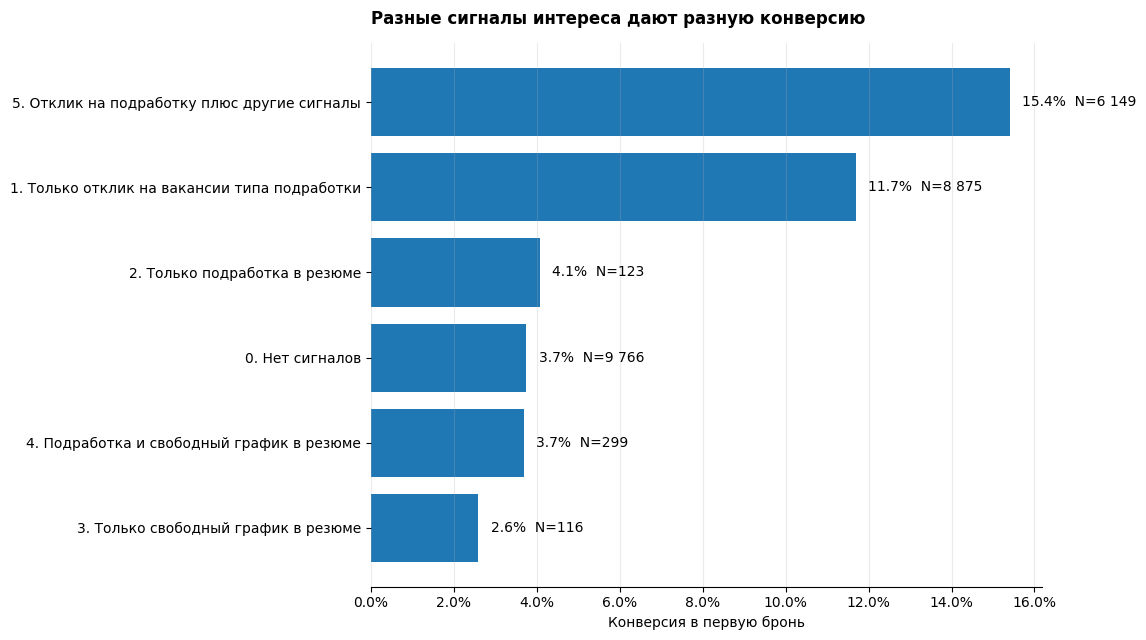

In [14]:
plot_df = interest_signal_groups.sort_values("booking_cr", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11.5, 6.5))
ax.barh(plot_df["interest_signal_group"], plot_df["booking_cr"])
ax.set_xlabel("Конверсия в первую бронь")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Разные сигналы интереса дают разную конверсию", loc="left", fontweight="bold", pad=14)
ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.booking_cr + 0.003, i, f"{pct(row.booking_cr)}  N={row.users:,}".replace(",", " "), va="center")

plt.tight_layout()
plt.show()

## 11. Формулировка гипотезы и механизм

Гипотеза остается такой: Пользователи с признаками интереса к подработке чаще бронируют первую смену в Авито Подработке

Механизм

У части этих пользователей уже есть потребность в гибкой занятости или дополнительном заработке, поэтому Авито Подработка не создает потребность с нуля, а попадает в уже понятный сценарий. Пользователь быстрее понимает ценность сервиса и чаще доходит до первой брони

Основная метрика это конверсия в первую бронь смены. Она показывает, что пользователь не просто посмотрел раздел, а сделал первый продуктовый шаг

Риск

Пользователи с признаками интереса могут быть просто более активными в Авито Работе, поэтому после основного теста отдельно проверим количество откликов на вакансии

## 12. Общая воронка пользователей

Перед проверкой гипотезы смотрим базовую воронку. Это нужно, чтобы понимать, где у продукта основное сужение

Как считаем

Каждый шаг считается как количество пользователей, у которых есть соответствующий флаг или событие. `Доля от всех` показывает размер шага от всего датасета. `Доля от прошлого шага` показывает переход внутри воронки

In [15]:
overall_funnel = pd.DataFrame({
    "stage": [
        "Все пользователи",
        "Начали верификацию",
        "Успешно прошли верификацию",
        "Забронировали первую смену",
        "Успешно завершили первую смену",
    ],
    "n": [
        len(df),
        int(df["started_verification_gu_flg"].sum()),
        int(df["success_verification_gu_flg"].sum()),
        int(df["booked_first_shift"].sum()),
        int(df["done_first_shift"].sum()),
    ],
})
overall_funnel["share_of_all"] = overall_funnel["n"] / len(df)
overall_funnel["share_of_previous"] = overall_funnel["n"] / overall_funnel["n"].shift(1)
overall_funnel.loc[0, "share_of_previous"] = 1

save_table(overall_funnel, "10_overall_funnel.csv")
display_formatted(
    overall_funnel,
    percent_cols=["share_of_all", "share_of_previous"],
    int_cols=["n"],
    max_rows=10,
)

,Шаг,Пользователи,Доля от всех,Доля от прошлого шага
0,Все пользователи,25 328,100.0%,100.0%
1,Начали верификацию,12 305,48.6%,48.6%
2,Успешно прошли верификацию,3 551,14.0%,28.9%
3,Забронировали первую смену,2 370,9.4%,66.7%
4,Успешно завершили первую смену,482,1.9%,20.3%


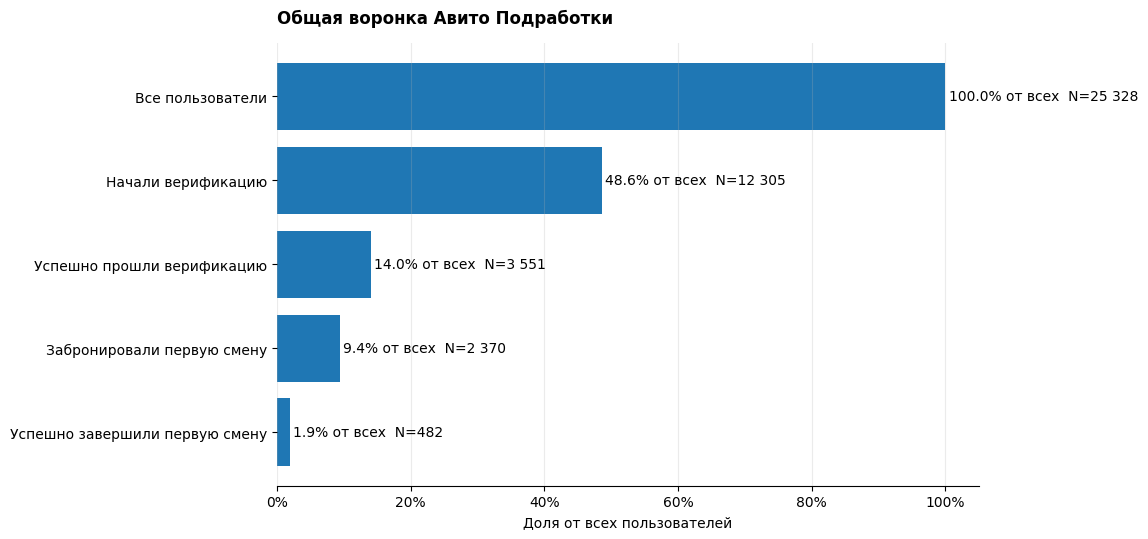

In [16]:
plot_df = overall_funnel.copy()

fig, ax = plt.subplots(figsize=(11.5, 5.5))
ax.barh(plot_df["stage"], plot_df["share_of_all"])
ax.invert_yaxis()
ax.set_xlabel("Доля от всех пользователей")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Общая воронка Авито Подработки", loc="left", fontweight="bold", pad=14)
ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for i, row in enumerate(plot_df.itertuples()):
    label = f"{pct(row.share_of_all)} от всех, N={row.n:,}".replace(",", " ")
    ax.text(row.share_of_all + 0.005, i, label, va="center")

plt.tight_layout()
plt.show()

## 13. Воронка по двум сегментам

Сравним воронку пользователей с признаками интереса и без них

Что это дает

Если сегмент с интересом лучше идет по ранним шагам, он может быть хорошей аудиторией для отдельной коммуникации. Отдельно проверим успешное завершение среди уже забронироввших смену, чтобы не перепутать рост брони с ростом качества выхода на смену

In [17]:
def build_funnel(data, segment):
    return pd.DataFrame({
        "segment": segment,
        "stage": [
            "Все пользователи",
            "Начали верификацию",
            "Успешно прошли верификацию",
            "Забронировали первую смену",
            "Успешно завершили первую смену",
        ],
        "n": [
            len(data),
            int(data["started_verification_gu_flg"].sum()),
            int(data["success_verification_gu_flg"].sum()),
            int(data["booked_first_shift"].sum()),
            int(data["done_first_shift"].sum()),
        ],
    })


funnel_by_segment = pd.concat([
    build_funnel(df[df["has_podrabotka_interest"] == 0], "Нет признаков интереса"),
    build_funnel(df[df["has_podrabotka_interest"] == 1], "Есть признаки интереса"),
], ignore_index=True)

segment_sizes = funnel_by_segment[funnel_by_segment["stage"] == "Все пользователи"][["segment", "n"]].rename(columns={"n": "segment_users"})
funnel_by_segment = funnel_by_segment.merge(segment_sizes, on="segment", how="left")
funnel_by_segment["share_of_segment"] = funnel_by_segment["n"] / funnel_by_segment["segment_users"]

save_table(funnel_by_segment, "11_funnel_by_segment.csv")
display_formatted(
    funnel_by_segment,
    percent_cols=["share_of_segment"],
    int_cols=["n", "segment_users"],
    max_rows=20,
)

,Сегмент,Шаг,Пользователи,Размер сегмента,Доля внутри сегмента
0,Нет признаков интереса,Все пользователи,9 766,9 766,100.0%
1,Нет признаков интереса,Начали верификацию,3 342,9 766,34.2%
2,Нет признаков интереса,Успешно прошли верификацию,624,9 766,6.4%
3,Нет признаков интереса,Забронировали первую смену,366,9 766,3.7%
4,Нет признаков интереса,Успешно завершили первую смену,78,9 766,0.8%
5,Есть признаки интереса,Все пользователи,15 562,15 562,100.0%
6,Есть признаки интереса,Начали верификацию,8 963,15 562,57.6%
7,Есть признаки интереса,Успешно прошли верификацию,2 927,15 562,18.8%
8,Есть признаки интереса,Забронировали первую смену,2 004,15 562,12.9%
9,Есть признаки интереса,Успешно завершили первую смену,404,15 562,2.6%


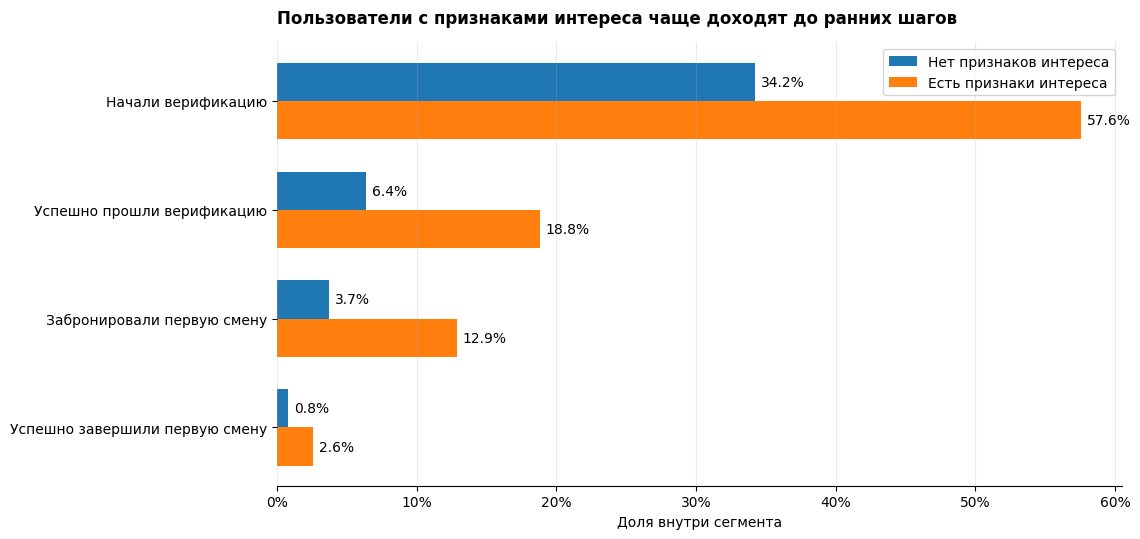

In [18]:
plot_df = funnel_by_segment[funnel_by_segment["stage"] != "Все пользователи"].copy()
pivot = plot_df.pivot(index="stage", columns="segment", values="share_of_segment")
stage_order = [
    "Начали верификацию",
    "Успешно прошли верификацию",
    "Забронировали первую смену",
    "Успешно завершили первую смену",
]
pivot = pivot.loc[stage_order]

y = np.arange(len(pivot))
height = 0.35

fig, ax = plt.subplots(figsize=(11.5, 5.5))
ax.barh(y - height / 2, pivot["Нет признаков интереса"], height=height, label="Нет признаков интереса")
ax.barh(y + height / 2, pivot["Есть признаки интереса"], height=height, label="Есть признаки интереса")
ax.set_yticks(y)
ax.set_yticklabels(pivot.index)
ax.invert_yaxis()
ax.set_xlabel("Доля внутри сегмента")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Пользователи с признаками интереса чаще доходят до ранних шагов", loc="left", fontweight="bold", pad=14)
ax.legend()
ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for i, stage in enumerate(pivot.index):
    for segment, y_pos in [("Нет признаков интереса", i - height / 2), ("Есть признаки интереса", i + height / 2)]:
        value = pivot.loc[stage, segment]
        ax.text(value + 0.004, y_pos, pct(value), va="center")

plt.tight_layout()
plt.show()

## 14. Основное сравнение по первой брони

Проверяем главную метрику: отличие конверсии в первую бронь у двух групп

Как считаем

Делим число пользователей с первой бронью на общее число пользователей в сегменте. Разница дана в процентных пунктах

In [19]:
booking_by_interest = (
    df.groupby("interest_segment")
    .agg(
        users=("booked_first_shift", "size"),
        booked=("booked_first_shift", "sum"),
        booking_cr=("booked_first_shift", "mean"),
    )
    .reset_index()
)

warm = df[df["has_podrabotka_interest"] == 1]
cold = df[df["has_podrabotka_interest"] == 0]

cr_warm = warm["booked_first_shift"].mean()
cr_cold = cold["booked_first_shift"].mean()
booking_diff = cr_warm - cr_cold

save_table(booking_by_interest, "12_booking_by_interest.csv")
display_formatted(
    booking_by_interest,
    percent_cols=["booking_cr"],
    int_cols=["users", "booked"],
    max_rows=10,
)

print(f"Разница: теплая аудитория минус аудитория без признаков интереса = {booking_diff * 100:.2f} п.п.")
print(f"Относительный прирост конверсии теплой аудитории: {(cr_warm / cr_cold - 1):.1%}")

,Сегмент интереса,Пользователи,Забронировали,Конверсия в первую бронь
0,Есть признаки интереса к подработке,15 562,2 004,12.9%
1,Нет признаков интереса к подработке,9 766,366,3.7%


Разница: теплая аудитория минус аудитория без признаков интереса = 9.13 п.п.
Относительный прирост конверсии теплой аудитории: 243.6%


## 15. Статистическая значимость основного результата

Простого сравнения процентов недостаточно. Нужно проверить, похожа ли разница на случайный шум

Используется z-тест для двух долей. Он подходит, так как метрика бинарна. Для каждой группы считается доля бронирований, а потом проверяется различие этих двух долей с учетом размера групп

Как это считается на уровне логики
1. Считаем конверсию в теплой аудитории и конверсию в аудитории без признаков интереса
2. Считаем разницу между ними
3. Тест оценивает, могла ли такая разница появиться случайно, если в реальности конверсии одинаковые. Чем больше разница и чем больше размер выборки, тем меньше вероятность, что это просто шум

p-value показывает вероятность увидеть такую или еще более сильную разницу при отсутствии реальной разницы между группами. Если p-value меньше 0.05, обычно говорят, что результат статистически значим на уровне 5 процентов. Это не значит, что гипотеза верна с вероятностью 95 процентов. Это значит, что такие данные плохо согласуются с идеей «разницы нет»

Дополнительно считаем доверительный интервал для разницы. Он показывает диапазон, где может лежать реальная разница в конверсии. Если весь интервал выше нуля, значит разница не только статистически значима, но и положительна

Еще считаем критерий хи-квадрат для таблицы 2 на 2, где по строкам лежат две группы пользователей, а по столбцам факт брони. Этот тест проверяет связь сегмента и брони. Для нашей задачи это дополнительная проверка, а не основной метод

In [20]:
successes = np.array([
    int(warm["booked_first_shift"].sum()),
    int(cold["booked_first_shift"].sum()),
])
nobs = np.array([len(warm), len(cold)])

z_stat, z_pvalue = proportions_ztest(successes, nobs)
ci_low, ci_high = confint_proportions_2indep(
    count1=successes[0], nobs1=nobs[0],
    count2=successes[1], nobs2=nobs[1],
    method="score",
)

contingency = np.array([
    [successes[0], nobs[0] - successes[0]],
    [successes[1], nobs[1] - successes[1]],
])
chi2_stat, chi2_pvalue, chi2_dof, chi2_expected = chi2_contingency(contingency)

stat_result = pd.DataFrame({
    "metric": [
        "Конверсия теплой аудитории",
        "Конверсия аудитории без признаков интереса",
        "Разница: теплая аудитория минус аудитория без признаков интереса",
        "95% доверительный интервал, нижняя граница",
        "95% доверительный интервал, верхняя граница",
        "p-value z-теста для двух долей",
        "p-value критерия хи-квадрат",
    ],
    "value": [cr_warm, cr_cold, booking_diff, ci_low, ci_high, z_pvalue, chi2_pvalue],
})

save_table(stat_result, "13_primary_stat_test.csv")

stat_display = stat_result.copy()
stat_display["value"] = stat_display.apply(
    lambda row: pct(row["value"]) if "Конверсия" in row["metric"] else (pp(row["value"] * 100) if "Разница" in row["metric"] or "доверительный интервал" in row["metric"] else pvalue_fmt(row["value"])),
    axis=1,
)
display(stat_display.rename(columns=RUSSIAN_COLUMN_NAMES))

,Показатель,Значение
0,Конверсия теплой аудитории,12.9%
1,Конверсия аудитории без признаков интереса,3.7%
2,Разница: теплая аудитория минус аудитория без ...,9.13 п.п.
3,"95% доверительный интервал, нижняя граница",8.49 п.п.
4,"95% доверительный интервал, верхняя граница",9.77 п.п.
5,p-value z-теста для двух долей,< 0.001
6,p-value критерия хи-квадрат,< 0.001


### Как читать результат

Конверсия в первую бронь у пользователей с признаками интереса заметно выше. Разница статистически значима, так как p-value меньше 0.05. Доверительный интервал целиком выше нуля, значит разница не только значима, но и положительна

Как это читать простыми словами

В данных разница между группами слишком большая, чтобы списать ее только на случайность, поэтому можно сказать, что связь между признаками интереса к подработке и первой бронью устойчива

Что это нам дает

Результат можно использовать как основание для продуктовой гипотезы и последующего эксперимента, но рано говорить, что сам признак интереса является причиной брони. Для причинного вывода нужно проверить альтернативные объяснения и лучше всего провести эксперимент

# Часть 3. Проверки устойчивости и альтернативные объяснения

Проверяем, не сломается ли результат из-за дублей, качества данных или третьих факторов. Самая важная проверка здесь связана с количеством откликов на вакансии. Это показатель общей активности пользователя в Авито Работе

## 16. Дубликаты по сегментам

В данных есть полные дубли. Важно посмотреть, где они лежат. Если дубли сконцентрированы только в одном сегменте, они могут искусственно менять конверсию

Как читать результат

Интересует не только общее количество дублей, но и их распределение по сегментам. Если дубли лежат в аудитории без признаков интереса, они могут занизить или завысить конверсию этой группы и тем самым повлиять на размер разницы

In [21]:
df["in_exact_duplicate_group"] = df_raw.duplicated(keep=False).astype(int)
df["would_be_removed_by_drop_duplicates"] = df_raw.duplicated().astype(int)

duplicate_by_segment = (
    df.groupby("interest_segment")
    .agg(
        users=("booked_first_shift", "size"),
        rows_in_duplicate_groups=("in_exact_duplicate_group", "sum"),
        rows_removed_by_drop_duplicates=("would_be_removed_by_drop_duplicates", "sum"),
        booking_cr=("booked_first_shift", "mean"),
    )
    .reset_index()
)
duplicate_by_segment["share_in_duplicate_groups"] = duplicate_by_segment["rows_in_duplicate_groups"] / duplicate_by_segment["users"]
duplicate_by_segment["share_removed_by_drop_duplicates"] = duplicate_by_segment["rows_removed_by_drop_duplicates"] / duplicate_by_segment["users"]

save_table(duplicate_by_segment, "14_duplicate_by_segment.csv")
display_formatted(
    duplicate_by_segment,
    percent_cols=["booking_cr", "share_in_duplicate_groups", "share_removed_by_drop_duplicates"],
    int_cols=["users", "rows_in_duplicate_groups", "rows_removed_by_drop_duplicates"],
    max_rows=10,
)

,Сегмент интереса,Пользователи,Строки в группах полных дублей,"Строки, которые удалит drop_duplicates",Конверсия в первую бронь,Доля строк в группах полных дублей,Доля строк к удалению
0,Есть признаки интереса к подработке,15 562,0,0,12.9%,0.0%,0.0%
1,Нет признаков интереса к подработке,9 766,3 394,2 455,3.7%,34.8%,25.1%


## 17. Проверка без полных дублей

Повторяем основную проверку после удаления полных дублей. Это не основной расчет, а проверка устойчивости

Как читать результат

Если эффект остается положительным и статистически значимым, значит вывод не держится только на полных дублях. Если эффект заметно меняется, это нужно честно учесть в ограничениях

Почему не делаем удаление основным сценарием

В данных нет идентификатора пользователя, поэтому нельзя доказать, что полный дубль это именно техническая ошибка. Из-за этого честнее показать оба расчета

In [22]:
df_no_exact_duplicates = df.drop_duplicates(subset=df_raw.columns.tolist()).copy()

warm_dedup = df_no_exact_duplicates[df_no_exact_duplicates["has_podrabotka_interest"] == 1]
cold_dedup = df_no_exact_duplicates[df_no_exact_duplicates["has_podrabotka_interest"] == 0]

successes_dedup = np.array([
    int(warm_dedup["booked_first_shift"].sum()),
    int(cold_dedup["booked_first_shift"].sum()),
])
nobs_dedup = np.array([len(warm_dedup), len(cold_dedup)])
z_dedup, p_dedup = proportions_ztest(successes_dedup, nobs_dedup)

robust_duplicates = pd.DataFrame({
    "variant": ["Основной расчет", "Без полных дублей"],
    "warm_users": [len(warm), len(warm_dedup)],
    "cold_users": [len(cold), len(cold_dedup)],
    "warm_cr": [cr_warm, warm_dedup["booked_first_shift"].mean()],
    "cold_cr": [cr_cold, cold_dedup["booked_first_shift"].mean()],
    "diff_pp": [booking_diff * 100, (warm_dedup["booked_first_shift"].mean() - cold_dedup["booked_first_shift"].mean()) * 100],
    "p_value": [z_pvalue, p_dedup],
})

save_table(robust_duplicates, "15_robust_duplicates.csv")
display_formatted(
    robust_duplicates,
    percent_cols=["warm_cr", "cold_cr"],
    pp_cols=["diff_pp"],
    pvalue_cols=["p_value"],
    int_cols=["warm_users", "cold_users"],
    max_rows=10,
)

,Вариант расчета,"Теплая аудитория, пользователей","Аудитория без признаков интереса, пользователей",Конверсия теплой аудитории,Конверсия аудитории без признаков интереса,"Разница, п.п.",p-value
0,Основной расчет,15 562,9 766,12.9%,3.7%,9.13 п.п.,< 0.001
1,Без полных дублей,15 562,7 311,12.9%,5.0%,7.87 п.п.,< 0.001


### Вывод по дублям

После удаления полных дублей эффект остается положительным и статистически значимым, но дубли лежат только в группе без признаков интереса, поэтому основной расчет немного завышает разницу между сегментами

Поэтому дальше читаем результат аккуратно. Связь есть, но точный размер эффекта лучше воспринимать как диапазон между основным расчетом и расчетом без полных дублей

## 18. Бронь и успешное завершение смены

Главная метрика исследования это первая бронь. Но для продукта важно не только забронировать смену, но и успешно ее завершить

Смотрим две вещи. Сначала долю успешных завершений от всех пользователей сегмента. Потом долю успешных завершений только среди тех, кто уже забронировал первую смену. Второй расчет показывает качество прохождения после брони

In [23]:
def two_prop_test(data, outcome, segment_col="has_podrabotka_interest"):
    g1 = data[data[segment_col] == 1]
    g0 = data[data[segment_col] == 0]
    counts = np.array([int(g1[outcome].sum()), int(g0[outcome].sum())])
    nobs_local = np.array([len(g1), len(g0)])
    z, p = proportions_ztest(counts, nobs_local)
    return counts, nobs_local, z, p


counts_done_all, nobs_done_all, z_done_all, p_done_all = two_prop_test(df, "done_first_shift")
booked_users = df[df["booked_first_shift"] == 1].copy()
counts_done_booked, nobs_done_booked, z_done_booked, p_done_booked = two_prop_test(booked_users, "done_first_shift")

completion_checks = pd.DataFrame({
    "metric": [
        "Забронировали первую смену от всех",
        "Успешно завершили первую смену от всех",
        "Успешно завершили среди забронировавших",
    ],
    "warm_n": [len(warm), len(warm), len(booked_users[booked_users["has_podrabotka_interest"] == 1])],
    "cold_n": [len(cold), len(cold), len(booked_users[booked_users["has_podrabotka_interest"] == 0])],
    "warm_rate": [cr_warm, counts_done_all[0] / nobs_done_all[0], counts_done_booked[0] / nobs_done_booked[0]],
    "cold_rate": [cr_cold, counts_done_all[1] / nobs_done_all[1], counts_done_booked[1] / nobs_done_booked[1]],
    "diff_pp": [
        (cr_warm - cr_cold) * 100,
        (counts_done_all[0] / nobs_done_all[0] - counts_done_all[1] / nobs_done_all[1]) * 100,
        (counts_done_booked[0] / nobs_done_booked[0] - counts_done_booked[1] / nobs_done_booked[1]) * 100,
    ],
    "p_value": [z_pvalue, p_done_all, p_done_booked],
})

save_table(completion_checks, "16_booking_and_completion.csv")
display_formatted(
    completion_checks,
    percent_cols=["warm_rate", "cold_rate"],
    pp_cols=["diff_pp"],
    pvalue_cols=["p_value"],
    int_cols=["warm_n", "cold_n"],
    max_rows=10,
)

,Показатель,"Теплая аудитория, пользователей","Аудитория без признаков интереса, пользователей",Доля теплой аудитории,Доля аудитории без признаков интереса,"Разница, п.п.",p-value
0,Забронировали первую смену от всех,15 562,9 766,12.9%,3.7%,9.13 п.п.,< 0.001
1,Успешно завершили первую смену от всех,15 562,9 766,2.6%,0.8%,1.80 п.п.,< 0.001
2,Успешно завершили среди забронировавших,2 004,366,20.2%,21.3%,-1.15 п.п.,0.615


### Как читать результат по успешным сменам

Теплая аудитория чаще доходит до успешного завершения первой смены, если считать от всех пользователей сегмента. Но это в основном потому, что она чаще бронирует

Если смотреть только на пользователей, которые уже забронировали первую смену, разницы в успешном завершении почти нет и она статистически незначима, поэтому сегмент с признаками интереса хорош именно для доведения до первой брони. По этим данным нельзя сказать, что он качественнее проходит смену после брони

## 19. Общая активность в Авито Работе

Это самая важная проверка альтернативного объяснения

`quantity_responses` показывает, на сколько вакансий пользователь откликался за последние полгода. Если пользователи с признаками интереса просто чаще откликаются на вакансии в целом, то более высокая бронь может объясняться не самим интересом к подработке, а общей активностью в поиске работы

Сначала смотрим распределение откликов, потом сравниваем конверсию внутри уровней активности

In [24]:
activity_summary = pd.DataFrame({
    "metric": ["50-й перцентиль", "75-й перцентиль", "90-й перцентиль", "95-й перцентиль", "99-й перцентиль", "Максимум", "Среднее"],
    "quantity_responses": [
        df["quantity_responses_num"].quantile(0.50),
        df["quantity_responses_num"].quantile(0.75),
        df["quantity_responses_num"].quantile(0.90),
        df["quantity_responses_num"].quantile(0.95),
        df["quantity_responses_num"].quantile(0.99),
        df["quantity_responses_num"].max(),
        df["quantity_responses_num"].mean(),
    ],
})

activity_by_interest = (
    df.groupby("interest_segment")
    .agg(
        users=("booked_first_shift", "size"),
        avg_quantity_responses=("quantity_responses_num", "mean"),
        median_quantity_responses=("quantity_responses_num", "median"),
        booking_cr=("booked_first_shift", "mean"),
    )
    .reset_index()
)

save_table(activity_summary, "17_activity_summary.csv")
save_table(activity_by_interest, "18_activity_by_interest.csv")

display(activity_summary.rename(columns=RUSSIAN_COLUMN_NAMES))
display_formatted(activity_by_interest, percent_cols=["booking_cr"], int_cols=["users"], max_rows=10)

,Показатель,Количество откликов
0,50-й перцентиль,3.000000
1,75-й перцентиль,14.000000
2,90-й перцентиль,44.000000
3,95-й перцентиль,76.000000
4,99-й перцентиль,180.730000
5,Максимум,852.000000
6,Среднее,15.992972


,Сегмент интереса,Пользователи,Среднее количество откликов,Медианное количество откликов,Конверсия в первую бронь
0,Есть признаки интереса к подработке,15 562,25.879514,10.0,12.9%
1,Нет признаков интереса к подработке,9 766,0.238890,0.0,3.7%


In [25]:
activity_bins = [-0.1, 0, 1, 3, 10, np.inf]
activity_labels = ["0 откликов", "1 отклик", "2 или 3 отклика", "4-10 откликов", "Больше 10 откликов"]
df["responses_bin"] = pd.cut(df["quantity_responses_num"], bins=activity_bins, labels=activity_labels)

activity_bin_table = (
    df.groupby(["responses_bin", "interest_segment"], observed=False)
    .agg(
        users=("booked_first_shift", "size"),
        booked=("booked_first_shift", "sum"),
        booking_cr=("booked_first_shift", "mean"),
    )
    .reset_index()
)
activity_bin_table["share_of_all"] = activity_bin_table["users"] / len(df)

save_table(activity_bin_table, "19_activity_bin_table.csv")
display_formatted(
    activity_bin_table,
    percent_cols=["booking_cr", "share_of_all"],
    int_cols=["users", "booked"],
    max_rows=20,
)

,Группа по количеству откликов,Сегмент интереса,Пользователи,Забронировали,Конверсия в первую бронь,Доля от всех
0,0 откликов,Есть признаки интереса к подработке,333,12,3.6%,1.3%
1,0 откликов,Нет признаков интереса к подработке,8 566,330,3.9%,33.8%
2,1 отклик,Есть признаки интереса к подработке,1 496,89,5.9%,5.9%
3,1 отклик,Нет признаков интереса к подработке,741,17,2.3%,2.9%
4,2 или 3 отклика,Есть признаки интереса к подработке,2 155,174,8.1%,8.5%
5,2 или 3 отклика,Нет признаков интереса к подработке,316,14,4.4%,1.2%
6,4-10 откликов,Есть признаки интереса к подработке,3 943,383,9.7%,15.6%
7,4-10 откликов,Нет признаков интереса к подработке,129,5,3.9%,0.5%
8,Больше 10 откликов,Есть признаки интереса к подработке,7 635,1 346,17.6%,30.1%
9,Больше 10 откликов,Нет признаков интереса к подработке,14,0,0.0%,0.1%


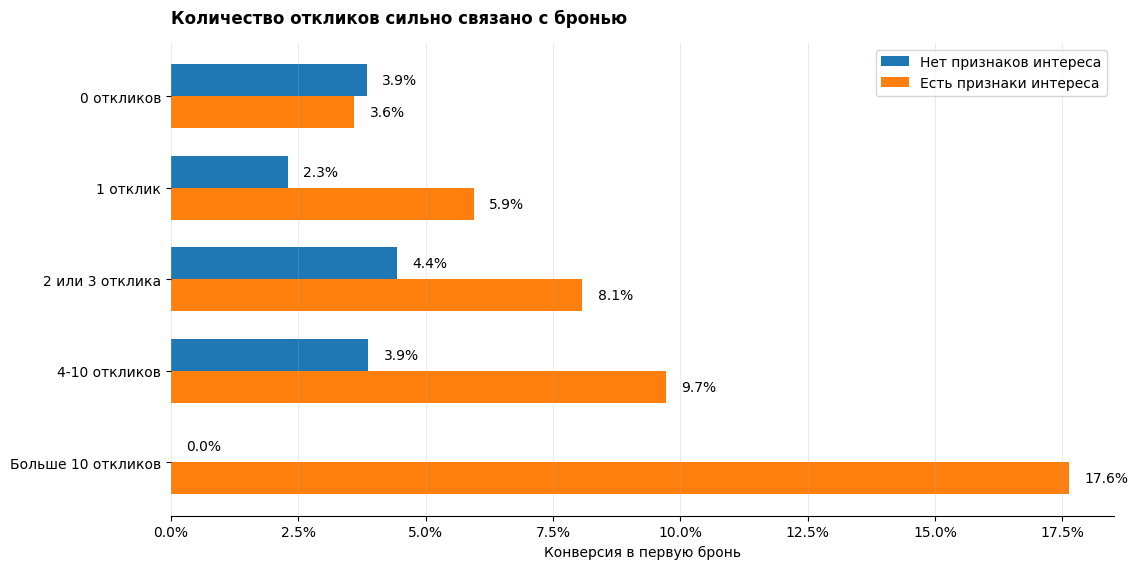

In [26]:
plot_df = activity_bin_table.copy()
pivot = plot_df.pivot(index="responses_bin", columns="interest_segment", values="booking_cr")
pivot = pivot.reindex(activity_labels)

y = np.arange(len(pivot))
height = 0.35

fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.barh(y - height / 2, pivot["Нет признаков интереса к подработке"], height=height, label="Нет признаков интереса")
ax.barh(y + height / 2, pivot["Есть признаки интереса к подработке"], height=height, label="Есть признаки интереса")
ax.set_yticks(y)
ax.set_yticklabels(pivot.index)
ax.invert_yaxis()
ax.set_xlabel("Конверсия в первую бронь")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Количество откликов сильно связано с бронью", loc="left", fontweight="bold", pad=14)
ax.legend()
ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for i, group in enumerate(pivot.index):
    for segment, y_pos in [("Нет признаков интереса к подработке", i - height / 2), ("Есть признаки интереса к подработке", i + height / 2)]:
        value = pivot.loc[group, segment]
        if pd.notna(value):
            ax.text(value + 0.003, y_pos, pct(value), va="center")

plt.tight_layout()
plt.show()

### Вывод по активности

Количество откликов сильно связано с первой бронью, а значит, общий сегмент теплой аудитории нельзя интерпретировать слишком прямолинейно

Наивное сравнение показывает большую разницу между теплой аудиторией и аудиторией без признаков интереса, но часть этой разницы может идти из-за того, что пользователи из теплой аудитории просто активнее в Авито Работе

Это важное альтернативное объяснение. Возможно, виден не «чистый интерес к подработке», а более широкая активность в поиске работы, поэтому в следующем шаге добавим количество откликов в модель как контрольную переменную

## 20. Эконометрическая проверка с контролями

Одного z-теста мало, так как группы отличаются: теплая аудитория может быть активнее, моложе, чаще сидеть на другой платформе или чаще получать маркетинговые коммуникации. Если это не учесть, есть риск приписать эффект признаку интереса, хотя часть разницы объясняется другими факторами

Для такой проверки используем линейную вероятностную модель - линейную регрессию с бинарной целевой переменной. В нашем случае `booked_first_shift` равен 1, если пользователь забронировал первую смену, и 0 иначе

Логика модели:

`вероятность брони = базовый уровень + эффект признаков интереса + эффекты контрольных переменных + случайная ошибка`

Коэффициент у признака интереса показывает, на сколько меняется вероятность первой брони при сравнении пользователей, похожих по добавленным контрольным переменным. Если коэффициент равен 0.05, это читается как плюс 5 процентных пунктов к вероятности брони

Контрольные переменные это признаки, которые могут одновременно быть связаны и с интересом к подработке, и с бронью. Здесь это демография, платформа, регион, количество откликов и маркетинговые касания. Мы не пытаемся построить идеальный прогноз, важно понять, что происходит с коэффициентом у признака интереса, когда эти факторы учтены

В модели используется поправка HC3 для стандартных ошибок. Простыми словами, она делает оценку статистической неопределенности более устойчивой, если разброс ошибок отличается между группами пользователей. Для бинарной метрики это особенно полезно, так как разброс рвзличен при разных уровнях вероятности

Как читать результат

Если после добавления количества откликов эффект сильно падает или меняет знак, значит наивная разница была частично объяснена общей активностью пользователей. Если эффект остается стабильным, значит признак интереса выглядит более самостоятельным фактором

In [27]:
model_rows = []

base_controls = "C(gender_model) + C(age_model) + C(income_model) + C(platform_model) + C(region_model)"
marketing_controls = " + ".join(marketing_flags)

formulas = {
    "1. Только признак интереса": "booked_first_shift ~ has_podrabotka_interest",
    "2. Плюс демография, платформа и регион": f"booked_first_shift ~ has_podrabotka_interest + {base_controls}",
    "3. Плюс общая активность": f"booked_first_shift ~ has_podrabotka_interest + log_quantity_responses + {base_controls}",
    "4. Плюс маркетинговые касания": f"booked_first_shift ~ has_podrabotka_interest + log_quantity_responses + {base_controls} + {marketing_controls}",
}

for model_name, formula in formulas.items():
    model = smf.ols(formula, data=df).fit(cov_type="HC3")
    coef = model.params["has_podrabotka_interest"]
    ci = model.conf_int().loc["has_podrabotka_interest"]
    model_rows.append({
        "model": model_name,
        "effect_of_interest_pp": coef * 100,
        "ci_low_pp": ci[0] * 100,
        "ci_high_pp": ci[1] * 100,
        "p_value": model.pvalues["has_podrabotka_interest"],
        "r2": model.rsquared,
    })

lpm_results = pd.DataFrame(model_rows)
save_table(lpm_results, "20_lpm_results.csv")
display_formatted(
    lpm_results,
    pp_cols=["effect_of_interest_pp", "ci_low_pp", "ci_high_pp"],
    pvalue_cols=["p_value"],
    max_rows=10,
)

,Модель,"Эффект признаков интереса, п.п.","Нижняя граница интервала, п.п.","Верхняя граница интервала, п.п.",p-value,R2 модели
0,1. Только признак интереса,9.13 п.п.,8.48 п.п.,9.78 п.п.,< 0.001,0.023282
1,"2. Плюс демография, платформа и регион",9.18 п.п.,8.52 п.п.,9.84 п.п.,< 0.001,0.055739
2,3. Плюс общая активность,-1.83 п.п.,-2.84 п.п.,-0.81 п.п.,< 0.001,0.082307
3,4. Плюс маркетинговые касания,-0.96 п.п.,-1.89 п.п.,-0.02 п.п.,0.045,0.223848


In [28]:
component_formula = (
    "booked_first_shift ~ vac_podrabotka_flg + cv_podrabotka_flg + cv_free_grafik_flg "
    f"+ log_quantity_responses + {base_controls}"
)
component_model = smf.ols(component_formula, data=df).fit(cov_type="HC3")

component_model_rows = []
for term, name in component_names.items():
    coef = component_model.params[term]
    ci = component_model.conf_int().loc[term]
    component_model_rows.append({
        "signal": name,
        "effect_pp_after_activity_control": coef * 100,
        "ci_low_pp": ci[0] * 100,
        "ci_high_pp": ci[1] * 100,
        "p_value": component_model.pvalues[term],
    })

component_model_rows.append({
    "signal": "Логарифм от количества откликов плюс один",
    "effect_pp_after_activity_control": component_model.params["log_quantity_responses"] * 100,
    "ci_low_pp": component_model.conf_int().loc["log_quantity_responses"][0] * 100,
    "ci_high_pp": component_model.conf_int().loc["log_quantity_responses"][1] * 100,
    "p_value": component_model.pvalues["log_quantity_responses"],
})

component_model_results = pd.DataFrame(component_model_rows)
save_table(component_model_results, "21_component_model_results.csv")
display_formatted(
    component_model_results,
    pp_cols=["effect_pp_after_activity_control", "ci_low_pp", "ci_high_pp"],
    pvalue_cols=["p_value"],
    max_rows=10,
)

,Сигнал,"Эффект после учета активности, п.п.","Нижняя граница интервала, п.п.","Верхняя граница интервала, п.п.",p-value
0,Откликался на вакансии типа подработки,-1.81 п.п.,-2.91 п.п.,-0.71 п.п.,0.001
1,Указал подработку в резюме,1.03 п.п.,-0.43 п.п.,2.48 п.п.,0.167
2,Указал свободный график в резюме,-0.84 п.п.,-2.33 п.п.,0.64 п.п.,0.266
3,Логарифм от количества откликов плюс один,4.78 п.п.,4.32 п.п.,5.24 п.п.,< 0.001


### Как читать модели

В первых двух моделях признак интереса выглядит сильным положительным фактором. Но после добавления количества откликов эффект резко меняется. Это не значит, что интерес к подработке вреден. Это значит, что широкий признак интереса сам по себе плохо отделяется от общей активности пользователя в Авито Работе

Главная интерпретация такая. В данных хорошо видна активная аудитория Авито Работы, которая чаще доходит до первой брони. А вот чистый самостоятельный эффект широкого флага `has_podrabotka_interest` доказан слабее

Важно понимать, что модель с контролями не превращает наблюдательные данные в эксперимент. Она только делает сравнение честнее. Мы сравниваем пользователей не просто «как есть», а с учетом части различий между ними. Но если в данных нет важного фактора, например настоящей мотивации пользователя или качества доступных смен, модель его не учтет

Маркетинговые касания читаем аккуратно. Это не идеальные внешние контроли. Они могут быть частью механизма или результатом таргетинга. Поэтому модель с маркетингом нужна как дополнительная проверка, а не как финальное доказательство причинности

## 21. Проверка по разрезам

Еще одна простая проверка устойчивости. Сравниваем теплую аудиторию и аудиторию без признаков интереса не только в целом, но и внутри отдельных групп. Например, отдельно внутри дохода, возраста, платформы и региона

Как читать результат

Если в большинстве групп теплая аудитория имеет более высокую конверсию, значит общий результат не держится только на одном разрезе. Например, результат не объясняется только одной платформой или одним регионом

Но эти разрезы не доказывают причинность. Это проверка устойчивости, которая помогает понять, насколько общий вывод повторяется внутри разных частей данных

In [29]:
df["has_item_view"] = (pd.to_numeric(df["item_view_frequency"], errors="coerce").fillna(0) > 0).astype(int)
df["has_item_view_label"] = df["has_item_view"].map({
    0: "Не открывал карточки смен",
    1: "Открывал карточки смен",
})

factor_names = {
    "income_model": "Доход",
    "age_model": "Возраст",
    "platform_model": "Платформа",
    "region_model": "Регион",
    "responses_bin": "Количество откликов",
    "has_item_view_label": "Открытие карточки смены",
    "click_internet_adv_flg": "Клик по интернет-рекламе",
    "opened_push_flg": "Открытие пуша",
    "watched_stories_in_app_flg": "Просмотр сторис",
    "click_addv_communication_flg": "Клик по внутренней коммуникации",
    "has_call_centre_communication_flg": "Звонок колл-центра",
}

factors_to_check = [
    "income_model", "age_model", "platform_model", "region_model", "responses_bin",
    "has_item_view_label", "click_internet_adv_flg", "opened_push_flg", "watched_stories_in_app_flg",
    "click_addv_communication_flg", "has_call_centre_communication_flg",
]

strata_rows = []
min_users_per_group = 30

for factor in factors_to_check:
    if factor not in df.columns:
        continue
    for group_value, g in df.groupby(factor, dropna=False, observed=False):
        warm_g = g[g["has_podrabotka_interest"] == 1]
        cold_g = g[g["has_podrabotka_interest"] == 0]
        if len(warm_g) < min_users_per_group or len(cold_g) < min_users_per_group:
            continue

        warm_success = int(warm_g["booked_first_shift"].sum())
        cold_success = int(cold_g["booked_first_shift"].sum())
        try:
            _, p_val = proportions_ztest([warm_success, cold_success], [len(warm_g), len(cold_g)])
        except Exception:
            p_val = np.nan

        strata_rows.append({
            "factor": factor,
            "factor_name": factor_names.get(factor, factor),
            "group": str(group_value),
            "warm_users": len(warm_g),
            "cold_users": len(cold_g),
            "warm_cr": warm_g["booked_first_shift"].mean(),
            "cold_cr": cold_g["booked_first_shift"].mean(),
            "diff_pp": (warm_g["booked_first_shift"].mean() - cold_g["booked_first_shift"].mean()) * 100,
            "p_value": p_val,
        })

strata_results = pd.DataFrame(strata_rows)
save_table(strata_results, "22_strata_results.csv")

strata_summary = (
    strata_results
    .groupby(["factor", "factor_name"])
    .agg(
        groups_checked=("group", "nunique"),
        groups_where_warm_higher=("diff_pp", lambda x: int((x > 0).sum())),
        significant_groups_5pct=("p_value", lambda x: int((x < 0.05).sum())),
        median_diff_pp=("diff_pp", "median"),
        min_diff_pp=("diff_pp", "min"),
        max_diff_pp=("diff_pp", "max"),
    )
    .reset_index()
)
strata_summary["share_groups_warm_higher"] = strata_summary["groups_where_warm_higher"] / strata_summary["groups_checked"]
strata_summary = strata_summary.sort_values("median_diff_pp", ascending=False)

save_table(strata_summary, "23_strata_summary.csv")
display_formatted(
    strata_summary[["factor_name", "groups_checked", "groups_where_warm_higher", "significant_groups_5pct", "share_groups_warm_higher", "median_diff_pp", "min_diff_pp", "max_diff_pp"]],
    percent_cols=["share_groups_warm_higher"],
    pp_cols=["median_diff_pp", "min_diff_pp", "max_diff_pp"],
    int_cols=["groups_checked", "groups_where_warm_higher", "significant_groups_5pct"],
    max_rows=20,
)

,Разрез,Проверено групп,"Групп, где теплая аудитория выше",Значимых групп на уровне 5%,"Доля групп, где теплая аудитория выше","Медианная разница, п.п.","Минимальная разница, п.п.","Максимальная разница, п.п."
2,Клик по интернет-рекламе,2,2,2,100.0%,15.15 п.п.,8.55 п.п.,21.75 п.п.
6,Открытие пуша,2,2,2,100.0%,12.08 п.п.,6.06 п.п.,18.11 п.п.
10,Просмотр сторис,2,2,2,100.0%,11.47 п.п.,7.93 п.п.,15.00 п.п.
7,Платформа,3,3,3,100.0%,9.54 п.п.,3.64 п.п.,9.86 п.п.
5,Доход,5,5,4,100.0%,8.37 п.п.,3.83 п.п.,11.67 п.п.
0,Возраст,6,6,5,100.0%,8.29 п.п.,5.23 п.п.,11.40 п.п.
8,Регион,16,16,10,100.0%,7.80 п.п.,0.53 п.п.,16.02 п.п.
1,Клик по внутренней коммуникации,1,1,1,100.0%,7.49 п.п.,7.49 п.п.,7.49 п.п.
4,Открытие карточки смены,2,2,1,100.0%,6.62 п.п.,0.02 п.п.,13.22 п.п.
3,Звонок колл-центра,2,2,1,100.0%,6.62 п.п.,5.15 п.п.,8.09 п.п.


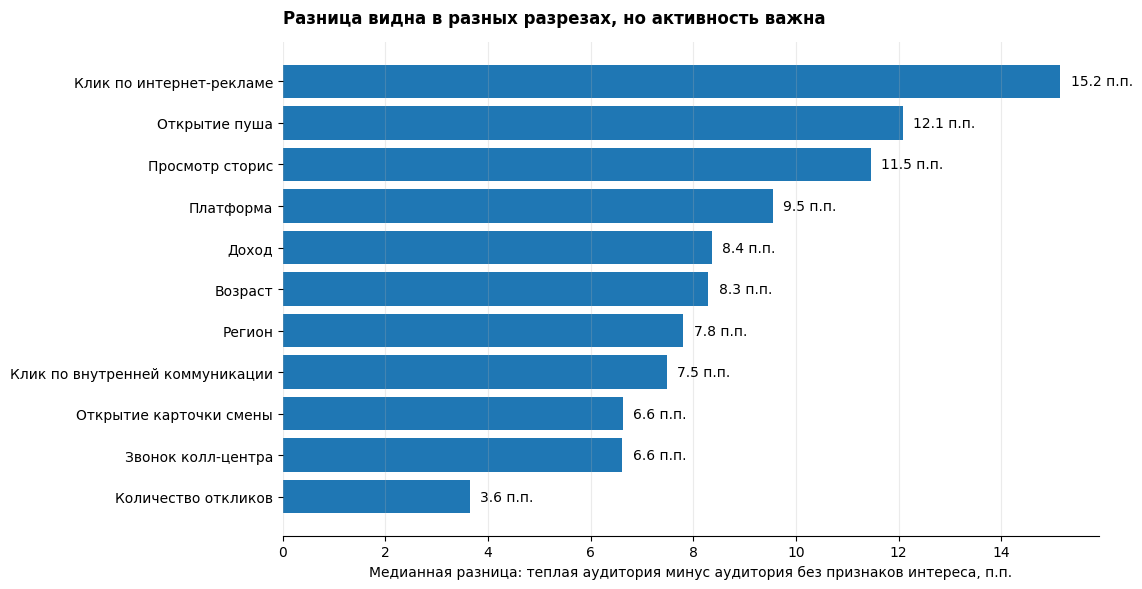

In [30]:
plot_df = strata_summary.sort_values("median_diff_pp", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11.5, 6))
ax.barh(plot_df["factor_name"], plot_df["median_diff_pp"])
ax.set_xlabel("Медианная разница: теплая аудитория минус аудитория без признаков интереса, п.п.")
ax.set_title("Разница видна в разных разрезах, но активность важна", loc="left", fontweight="bold", pad=14)
ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.median_diff_pp + 0.2, i, f"{row.median_diff_pp:.1f} п.п.", va="center")

plt.tight_layout()
plt.show()

### Вывод по разрезам

В большинстве проверенных разрезов теплая аудитория показывает более высокую конверсию в первую бронь. Это поддерживает общий описательный вывод

Разрезы не снимают главный риск. Пользователи отличаются по общей активности в Авито Работе, что сильно связано с бронью, поэтому финальный вывод должен быть аккуратным

# Часть 4. Итоговые выводы и применение

## 22. Основные выводы

1. В данных есть сильная статистически значимая связь между признаками интереса к подработке и первой бронью смены. В наивном сравнении пользователи с признаками интереса бронируют смену чаще примерно на 9 п.п.

2. z-тест для двух долей выбран корректно. Метрика бинарная, группы большие, поэтому тест подходит. Доверительный интервал для разницы целиком выше нуля, значит разница положительная и статистически значимая

3. Дубликаты не ломают вывод, но влияют на размер эффекта. Полные дубли находятся только в группе без признаков интереса. После удаления дублей разница остается положительной, но становится меньше

4. Общий сегмент теплой аудитории неоднородный. Сигналы из резюме без отклика на вакансии типа подработки почти не отличаются от группы без признаков интереса. Основной сильный сигнал связан с активностью в Авито Работе и откликами на вакансии типа подработки

5. После контроля количества откликов на вакансии широкий признак интереса уже не выглядит как самостоятельный положительный фактор, поэтому нельзя писать, что интерес к подработке сам по себе вызывает первую бронь

6. Теплая аудитория лучше подходит для доведения до первой брони. Среди тех, кто уже забронировал смену, статистически значимой разницы в успешном завершении первой смены нет

## 23. Ограничения исследования

1. Данные наблюдательные. Пользователей не распределяли случайно в группы, поэтому мы доказываем устойчивую связь, но не финальную причинность

2. У признаков интереса нет времени события. Не всегда можно проверить, что интерес появился строго до первой брони. Это риск обратной связи

3. В данных нет идентификатора пользователя `user_id`. Из-за этого полные дубли нельзя трактовать однозначно. Основной расчет сделан на всех строках, а расчет без полных дублей показан отдельно

4. Количество откликов на вакансии сильно влияет на результат. Это значит, что часть эффекта теплой аудитории объясняется общей активностью пользователя в Авито Работе

5. Маркетинговые касания нельзя читать как причинный эффект каналов. Например, если пользователь открыл пуш, это не значит, что именно пуш вызвал бронь. Возможно, коммуникации чаще получали уже более подходящие пользователи

6. Ставка, длительность и тип задания первой смены не подходят для объяснения первой брони. Эти данные появляются уже после выбора смены, поэтому использовать их как причину брони некорректно

## 24. Практическое применение для Авито Подработки

Главный практический вывод не в том, что нужно просто больше рекламы на всех пользователей с любым сигналом теплой аудитории. Лучше точнее работать с активной аудиторией Авито Работы

Что можно сделать

1. Выделить пользователей, которые активно откликаются на вакансии и уже взаимодействовали с вакансиями типа подработки. Это более надежный сегмент, чем просто наличие свободного графика в резюме

2. Запустить отдельную коммуникацию про Авито Подработку. Сообщение лучше строить вокруг понятной пользы. Пользователь может выбрать смену, не проходить собеседования, выйти в удобное время и получить оплату день в день

3. Доводить активных пользователей до первой брони. Если пользователь заинтересован, но не дошел до брони, стоит подсветить ближайшие смены, объяснить верификацию и убрать непонимание на первом шаге

4. Не обещать рост успешного завершения смены только за счет этого сегмента. По данным видно, что после брони пользователи с признаками интереса и без признаков интереса завершают первую смену примерно одинаково

## 25. Что проверять дальше через эксперимент

Наблюдательные данные дают основание для эксперимента, но не заменяют его

Я бы тестировала отдельную коммуникацию на активной аудитории Авито Работы. В контрольной группе пользователь видит текущий опыт. В тестовой группе получает более явный вход в Авито Подработку и короткое объяснение ценности сервиса

Основная метрика эксперимента это конверсия в первую бронь. Вторичные метрики это старт верификации, успешная верификация и успешное завершение первой смены. Защитные метрики это отмены, невыходы на смену, жалобы и нагрузка на доступные смены

Важно сравнивать пользователей с похожим уровнем активности, иначе эксперимент снова смешает эффект коммуникации с тем, что одни пользователи изначально активнее других

## 26. Финальный вывод

Гипотеза подтверждается только в аккуратной формулировке. В данных есть статистически значимая связь между признаками интереса к подработке и первой бронью смены. Наивное сравнение показывает большой прирост конверсии

Более строгая проверка показывает, что широкий сегмент теплой аудитории сильно связан с общей активностью в Авито Работе. После контроля количества откликов нельзя уверенно сказать, что факт интереса к подработке является самостоятельной причиной брони

Для продукта это все равно полезный результат. Рост первой брони стоит искать в работе с активными пользователями Авито Работы, особенно с теми, кто уже взаимодействовал с вакансиями типа подработки. Следующий правильный шаг это эксперимент с контрольной и тестовой группой на этой аудитории

## 27. Сохранение подготовленных данных и краткого резюме

В подготовленный файл добавлены только технические признаки для анализа. Исходные строки в основном анализе не удалялись

Краткое резюме сохраняется отдельной таблицей. Оно нужно, чтобы быстро восстановить логику исследования

In [31]:
prepared_path = OUT / "dataset_avito_prepared_for_analysis.csv"
df.to_csv(prepared_path, index=False)

project_summary = pd.DataFrame({
    "block": [
        "Гипотеза",
        "Основная метрика",
        "Очистка данных",
        "Проверка дубликатов",
        "Статистические методы",
        "Проверка альтернативных объяснений",
        "Главное ограничение",
        "Практическое применение",
    ],
    "result": [
        "Пользователи с признаками интереса к подработке чаще бронируют первую смену",
        "Конверсия в первую бронь смены",
        "Строки без явной причины не удалялись, пропуски и логические нюансы зафиксированы",
        "Основной расчет на всех строках, отдельная проверка без полных дублей",
        "z-тест для двух долей, доверительный интервал, критерий хи-квадрат, линейная вероятностная модель с контролями",
        "Добавлены контроли по демографии, платформе, региону, маркетингу и количеству откликов",
        "После контроля общей активности широкий флаг теплой аудитории не доказывает самостоятельный причинный эффект",
        "Тестировать коммуникацию на активных пользователях Авито Работы через эксперимент с контрольной и тестовой группой",
    ],
})
summary_path = OUT / "project_summary.csv"
project_summary.to_csv(summary_path, index=False)

display(project_summary.rename(columns=RUSSIAN_COLUMN_NAMES))
print(f"Подготовленный датасет сохранен: {prepared_path}")
print(f"Краткое резюме сохранено: {summary_path}")

,Блок,Результат
0,Гипотеза,Пользователи с признаками интереса к подработк...
1,Основная метрика,Конверсия в первую бронь смены
2,Очистка данных,"Строки без явной причины не удалялись, пропуск..."
3,Проверка дубликатов,"Основной расчет на всех строках, отдельная про..."
4,Статистические методы,"z-тест для двух долей, доверительный интервал,..."
5,Проверка альтернативных объяснений,"Добавлены контроли по демографии, платформе, р..."
6,Главное ограничение,После контроля общей активности широкий флаг т...
7,Практическое применение,Тестировать коммуникацию на активных пользоват...


Подготовленный датасет сохранен: avito_case_final_results/dataset_avito_prepared_for_analysis.csv
Краткое резюме сохранено: avito_case_final_results/project_summary.csv


Для выгрузки папки примонтирую свой диск

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
!cp -r avito_case_final_results/ /content/drive/MyDrive/